# Linear Regression, Part 2

Two examples:

1. **Draft lottery (1970 vs 1971)** — assessing parameters and model fit. 
2. **Palmer penguins** — multiple linear regression.

## Draft Lottery Example

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# In Dec 1969 the Selective Service drew capsules to assign draft order to birthdays.
# Each day of the year got a rank from 1-366. Rank 1 was drafted first.
# The 1970 drawing was widely criticized as non-random; procedures were changed for 1971.
draft1970 = pd.read_csv("../data/draft_lottery1970.csv")
draft1971 = pd.read_csv("../data/draft_lottery1971.csv")

draft1970.head()

,day_of_year,lottery_rank,month
0,1,305,1
1,2,159,1
2,3,251,1
3,4,215,1
4,5,101,1


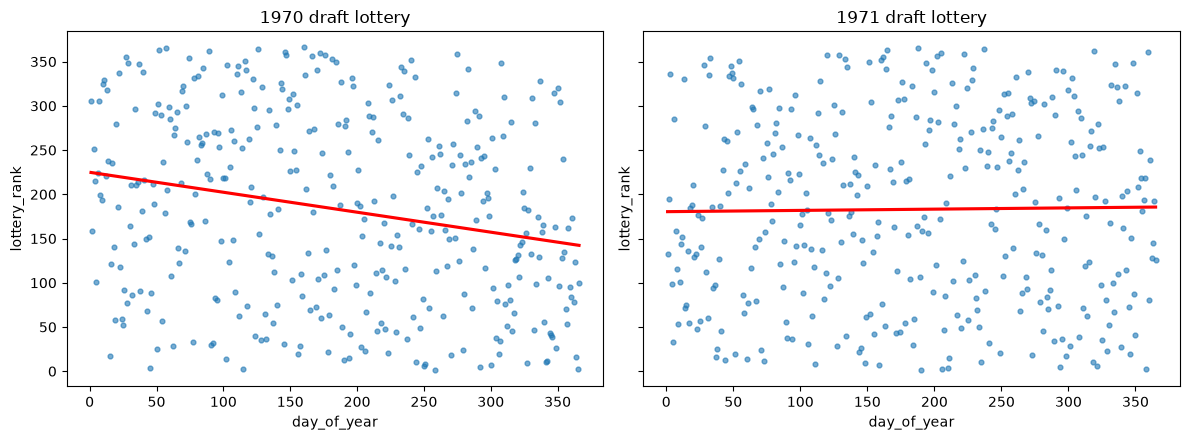

In [2]:
# Do a simple scatter plot of each of the data sets using matplotlib and seaborn. 

# Note--the sharey=True parameter means both subplots have the same y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (year, df) in zip(axes, [(1970, draft1970), (1971, draft1971)]):
    sns.regplot(data=df, x="day_of_year", y="lottery_rank", ci=None,
                ax=ax, scatter_kws={"s": 12, "alpha": 0.6},
                line_kws={"color": "red"})
    ax.set_title(f"{year} draft lottery")
plt.tight_layout()

In [3]:
# Now let's look at whether or not there is a correlation between day of year and lottery rank
# A fair system would mean that there would be NO correlation between day of year and lottery rank

draft1970.corr()

,day_of_year,lottery_rank,month
day_of_year,1.000000,-0.225686,0.996516
lottery_rank,-0.225686,1.000000,-0.230844
month,0.996516,-0.230844,1.000000


In [4]:
# Now let's do the same for 1971
draft1971.corr()

,day_of_year,lottery_rank,month
day_of_year,1.000000,0.014249,0.996504
lottery_rank,0.014249,1.000000,0.017979
month,0.996504,0.017979,1.000000


In [5]:
# Now let's buid a linear regression model to predict lottery rank based on day of year.
# We will do this for each year and output the results side by side. 

# Write a tiny function
def fit_lottery(df):
    X = sm.add_constant(df["day_of_year"])
    return sm.OLS(df["lottery_rank"], X).fit()

# Call it twice
model1970 = fit_lottery(draft1970)
model1971 = fit_lottery(draft1971)

# Summarize the results in a dataframe
summary = pd.DataFrame({
    year: {
        "n":         int(m.nobs),
        "r":         df["day_of_year"].corr(df["lottery_rank"]),
        "R^2":       m.rsquared,
        "slope":     m.params.iloc[1],
        "SE(slope)": m.bse.iloc[1],
        "t":         m.tvalues.iloc[1],
        "p-value":   m.pvalues.iloc[1],
        "RSE":       np.sqrt(m.scale),
    }
    for year, m, df in [(1970, model1970, draft1970), (1971, model1971, draft1971)]
})

# Format per row so the 1970 p-value doesn't round away to 0.0000
fmt = {"n": "{:.0f}", "r": "{:+.4f}", "R^2": "{:.4f}", "slope": "{:+.4f}",
       "SE(slope)": "{:.4f}", "t": "{:+.3f}", "p-value": "{:.6f}", "RSE": "{:.1f}"}
summary.apply(lambda row: row.map(fmt[row.name].format), axis=1)

,1970,1971
n,366,365
r,-0.2257,+0.0142
R^2,0.0509,0.0002
slope,-0.2257,+0.0142
SE(slope),0.0511,0.0525
t,-4.420,+0.272
p-value,0.000013,0.786149
RSE,103.2,105.6


There are a few things to note from the above table:
* Because this is a simple linear regression, R^2 = r^2, where r is the correlation between x and y.
* In both cases the R^2 value is relatively low, meaning that a lot of the variability in y is NOT explained by the model. (This also is reflected in the charts above)
* Even so, the p-value for the slope for the 1970s dataset is significant! 

1970 mean rank by month:
month
1     201.2
2     203.0
3     225.8
4     203.7
5     208.0
6     195.7
7     181.5
8     173.5
9     157.3
10    182.5
11    148.7
12    121.5


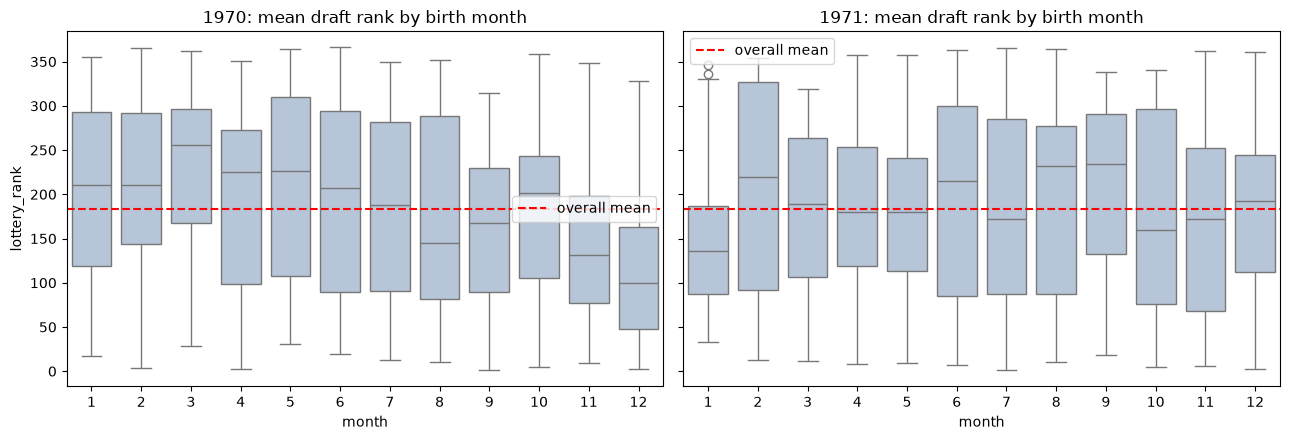

In [6]:
# Let's take another look at what is going on here:

# Where does the 1970 signal come from? Look at mean rank by month.
# The capsules were loaded January -> December and poorly mixed, so late-year
# birthdays sat on top of the bowl and were drawn early (= low rank = drafted first).

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (year, df) in zip(axes, [(1970, draft1970), (1971, draft1971)]):
    sns.boxplot(data=df, x="month", y="lottery_rank", ax=ax, color="lightsteelblue")
    ax.axhline(df["lottery_rank"].mean(), color="red", ls="--", label="overall mean")
    ax.set_title(f"{year}: mean draft rank by birth month")
    ax.legend()
plt.tight_layout()

print("1970 mean rank by month:")
print(draft1970.groupby("month")["lottery_rank"].mean().round(1).to_string())

In [7]:
# Now, let's add the fitted values and residuals to each of the datasets and plot them
def add_to_df(df, model):  
    out = df.copy() # This is ok here--beware for large datasets! 
    out["fitted"]=model.fittedvalues
    out["residuals"]=model.resid
    return out 

draft1970 = add_to_df(draft1970, model1970)
draft1971 = add_to_df(draft1971, model1971)


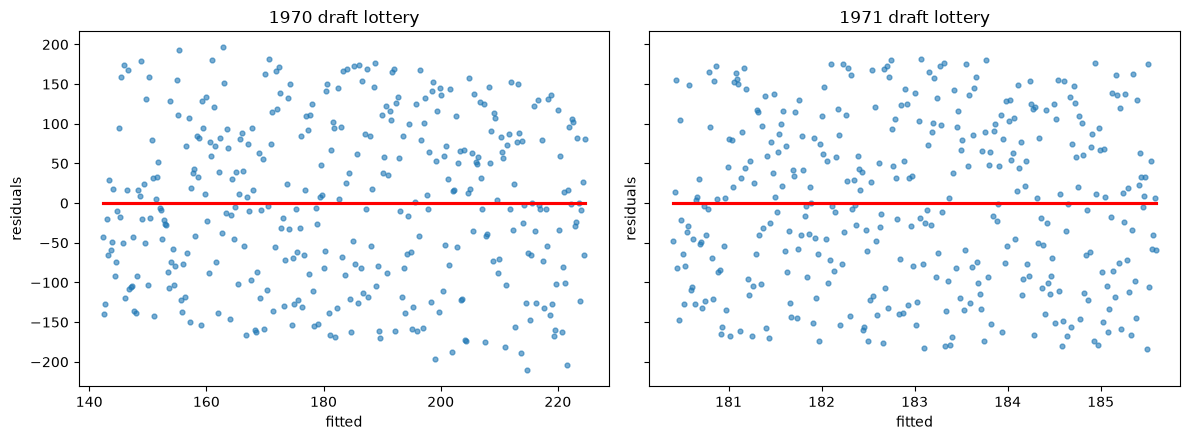

In [8]:
# Now let's look at fitted vs residuals using the same code as above. 

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (year, df) in zip(axes, [(1970, draft1970), (1971, draft1971)]):
    sns.regplot(data=df, x="fitted", y="residuals", ci=None,
                ax=ax, scatter_kws={"s": 12, "alpha": 0.6},
                line_kws={"color": "red"})
    ax.set_title(f"{year} draft lottery")
plt.tight_layout()

## The Penguins are Back!

This time with more predictors. :) 

In [9]:
penguins = pd.read_csv("../data/penguins.csv")

# Keep rows with all four measurements so every model below is fit on the SAME rows.
# (Comparing R^2 across models fit on different samples is meaningless.)
peng = penguins.dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

print(f"n = {len(peng)}")
peng.head()

n = 342


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


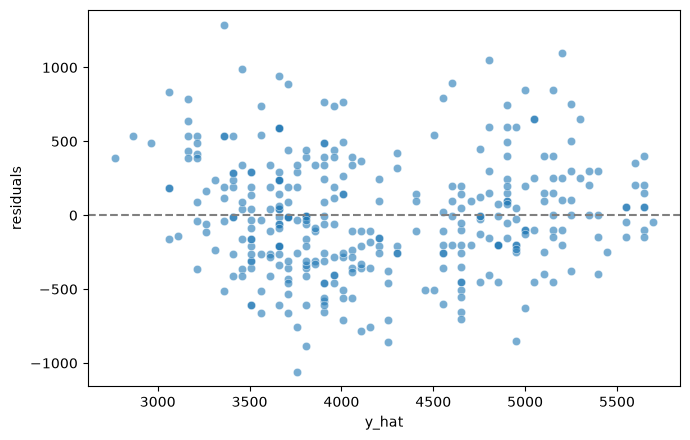

In [10]:
# Refit the simple model from last time, and plot the residuals.

simple = sm.OLS(peng["body_mass_g"],
                sm.add_constant(peng["flipper_length_mm"])).fit()
peng["y_hat"] = simple.fittedvalues
peng["residuals"] = simple.resid

resid_ylim = (peng["residuals"].min() - 100, peng["residuals"].max() + 100)

plt.figure(figsize=(7, 4.5))
ax = sns.scatterplot(data=peng, x="y_hat", y="residuals", alpha=0.6)
ax.axhline(0, color="gray", ls="--")
ax.set_ylim(resid_ylim)
plt.tight_layout()

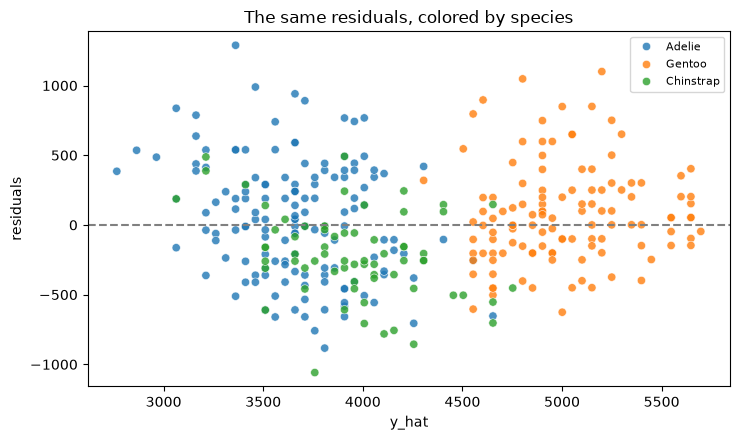

In [11]:
plt.figure(figsize=(7.5, 4.5))
ax = sns.scatterplot(data=peng.dropna(subset=["sex"]), x="y_hat", y="residuals",
                     hue="species", alpha=0.8)
ax.axhline(0, color="gray", ls="--")
ax.set_ylim(resid_ylim)
ax.set_title("The same residuals, colored by species")
ax.legend(fontsize=8)
plt.tight_layout()

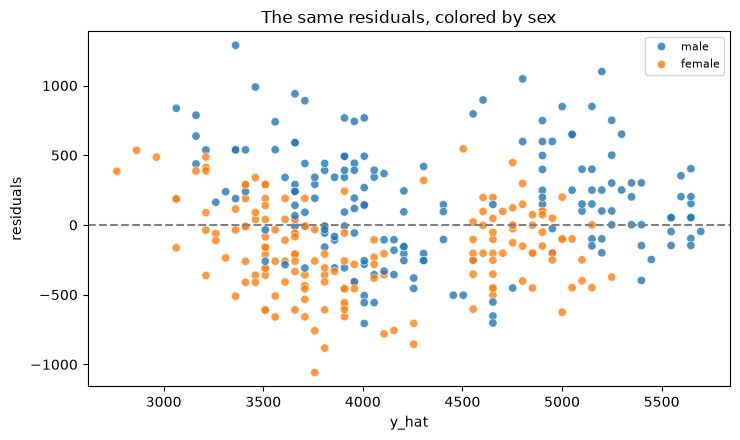

In [12]:
plt.figure(figsize=(7.5, 4.5))
ax = sns.scatterplot(data=peng.dropna(subset=["sex"]), x="y_hat", y="residuals",
                     hue="sex", alpha=0.8)
ax.axhline(0, color="gray", ls="--")
ax.set_ylim(resid_ylim)
ax.set_title("The same residuals, colored by sex")
ax.legend(fontsize=8)
plt.tight_layout()

In [13]:
# Let's add some predictors to this analysis.
# (Species and sex categorical -- we'll handle that in a couple of weeks.)

# We are now going to build a base model with flipper length as a predictor only
# We'll then look at adding in bill_length and bill_depth

specs = [
    ["flipper_length_mm"],
    ["flipper_length_mm", "bill_length_mm"],
    ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"],
]

rows = []
fitted_models = []
for cols in specs:
    m = sm.OLS(peng["body_mass_g"], sm.add_constant(peng[cols])).fit()
    fitted_models.append(m)
    rows.append({
        "predictors": " + ".join(c.replace("_mm", "") for c in cols),
        "R^2": m.rsquared,
        "Adj R^2": m.rsquared_adj,
        "RSE": np.sqrt(m.scale),
        "F": m.fvalue,
    })

pd.DataFrame(rows).round(4)

,predictors,R^2,Adj R^2,RSE,F
0,flipper_length,0.7590,0.7583,394.2782,1070.7446
1,flipper_length + bill_length,0.7600,0.7585,394.0678,536.6255
2,flipper_length + bill_length + bill_depth,0.7615,0.7594,393.4048,359.6718


In [14]:
# We can also look at the t-statistics and p-values for each of these predictors

full = fitted_models[-1]
print(full.summary().tables[1])

# To look at the full OLS results for any of these models we could run
# print(fitted_models[0].summary())

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -6424.7647    561.469    -11.443      0.000   -7529.179   -5320.351
flipper_length_mm    50.2692      2.477     20.293      0.000      45.397      55.142
bill_length_mm        4.1618      5.329      0.781      0.435      -6.321      14.644
bill_depth_mm        20.0495     13.694      1.464      0.144      -6.887      46.986


In [15]:
# This tells us that neither new predictor is significant when added to this model.
# Are either bill_length or bill_depth correlated with body_mass on their own? 
peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm", "body_mass_g"]].corr()

,flipper_length_mm,bill_length_mm,bill_depth_mm,body_mass_g
flipper_length_mm,1.000000,0.656181,-0.583851,0.871202
bill_length_mm,0.656181,1.000000,-0.235053,0.595110
bill_depth_mm,-0.583851,-0.235053,1.000000,-0.471916
body_mass_g,0.871202,0.595110,-0.471916,1.000000


In [16]:
# Let's break this down a bit so it is easier to read

print("simple correlation with body_mass_g:")
print(peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm", "body_mass_g"]]
      .corr()["body_mass_g"].drop("body_mass_g").round(4).to_string())

simple correlation with body_mass_g:
flipper_length_mm    0.8712
bill_length_mm       0.5951
bill_depth_mm       -0.4719


In [17]:
# What if we built a model predicting mass just as a function of bill length

import statsmodels.api as sm

X = sm.add_constant(peng["bill_length_mm"])
y = peng["body_mass_g"]

results = sm.OLS(y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     186.4
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           3.81e-34
Time:                        11:49:03   Log-Likelihood:                -2697.0
No. Observations:                 342   AIC:                             5398.
Df Residuals:                     340   BIC:                             5406.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            362.3067    283.345      1.

In [18]:
print("\ncorrelation AMONG the predictors:")
print(peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]].corr().round(3))
print("\nThe predictors carry overlapping information -- more on this next week.")


correlation AMONG the predictors:
                   flipper_length_mm  bill_length_mm  bill_depth_mm
flipper_length_mm              1.000           0.656         -0.584
bill_length_mm                 0.656           1.000         -0.235
bill_depth_mm                 -0.584          -0.235          1.000

The predictors carry overlapping information -- more on this next week.
